# Regression

- Author: Arnold Atchoe.
- Date: 2026-07
- Dataset: Advertising Dataset
- Target: sales
- Source: https://www.geeksforgeeks.org/machine-learning/dataset-for-linear-regression/

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M4. Regression

This notebook fits a line and computes the numbers analysts use to judge a fit:

- R-squared
- RMSE
- residuals
  
It shows how complexity changes train vs. test error. 

The analyst decides whether the fit is "good" and 
how much complexity is right. 
Code calculates values, but the analyst decides.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

## Overview

This project uses an advertising dataset located in `data/raw/advertising.csv`
We choose to predict the target `Sales` given the amount of money spent to advertise on `TV`,`Radio` and in the `Newspaper`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. When to Use Regression, and How We Judge It

Use **regression** when the target is a **number** - mass, price, temperature,
demand. (A category target is classification, Module 3.)

We judge a regression on held-out data, with:

- **R-squared** - the fraction of the variation in the target the model explains
  (roughly 0 to 1; higher is more).
- **RMSE** - root mean squared error, the typical size of a miss, in the target's units.
- **residual plot** - actual minus predicted. If a straight line fits well, residuals
  scatter randomly around zero with no pattern. A curve or a funnel says the line is
  the wrong shape - itself a useful finding.

**Over- vs. under-fitting:** a model too simple **underfits** (misses real structure;
poor on both train and test). A model too complex **overfits** (memorizes the training
data; great on train, worse on test). You detect it by comparing train and test error
as complexity changes - Section 6.

## Section 1. Project Setup and Imports

In [53]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
from pathlib import Path
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04", level="DEBUG")
log_header(LOG, "M04")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-26 15:20:29 | INFO | M04 | === RUN START ===
2026-07-26 15:20:29 | INFO | M04 | project=M04
2026-07-26 15:20:29 | INFO | M04 | repo_dir=ml-04-regression
2026-07-26 15:20:29 | INFO | M04 | python=3.14.6
2026-07-26 15:20:29 | INFO | M04 | os=Windows 11
2026-07-26 15:20:29 | INFO | M04 | shell=powershell
2026-07-26 15:20:29 | INFO | M04 | cwd=notebooks
2026-07-26 15:20:29 | INFO | M04 | github_actions=False
2026-07-26 15:20:29 | INFO | M04 | Confirming installation:
2026-07-26 15:20:29 | INFO | M04 |   python:       3.14.6
2026-07-26 15:20:29 | INFO | M04 |   pandas:       3.0.5
2026-07-26 15:20:29 | INFO | M04 |   numpy:        2.5.1
2026-07-26 15:20:29 | INFO | M04 |   scikit-learn: 1.9.0
2026-07-26 15:20:29 | INFO | M04 |   seaborn:      0.13.2
2026-07-26 15:20:29 | INFO | M04 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [60]:
# === Section 2. Load and Prepare the Data ===

# We are loading data from from data/raw/advertising.csv,
# which is a small dataset made of 200 rows.

# Define Constants
DATASET_NAME: Final[str] = "advertising.csv"
CURRENT_DIR: Final[Path] = Path.cwd().parent
DATASET_DIR: Final[Path] = CURRENT_DIR / "data" / "raw"
DATASET_PATH: Final[Path] = DATASET_DIR / DATASET_NAME

# Load the dataset into a pandas DataFrame and check number of rows and columns
LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv(DATASET_PATH)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")


# ANALYST CHOICE - Three numeric features (x1, x2, x3) and one numeric target (y).
# This pairing is expected to be close to a straight line; we still fit and look.
FEATURE_COL_1: Final[str] = "TV"
FEATURE_COL_2: Final[str] = "Radio"
FEATURE_COL_3: Final[str] = "Newspaper"
TARGET_COL: Final[str] = "Sales"

# Check for duplicate values in the selected columns before modeling
LOG.info(
    f"Duplicate values in the original dataset:\n{df[[FEATURE_COL_1, FEATURE_COL_2, FEATURE_COL_3, TARGET_COL]].duplicated().sum()}"
)
# Drop duplicate rows in the selected columns before modeling
df = df.drop_duplicates(
    subset=[FEATURE_COL_1, FEATURE_COL_2, FEATURE_COL_3, TARGET_COL]
)

df_model: pd.DataFrame = df.dropna(
    subset=[FEATURE_COL_1, FEATURE_COL_2, FEATURE_COL_3, TARGET_COL]
).copy()
LOG.info(f"Missing values:\n{df_model.isna().sum()}")
LOG.info(f"Basic statistics:\n{df_model.describe()}")
LOG.info("Outliers (using IQR method):")
Q1_1: float = df_model[FEATURE_COL_1].quantile(0.25)
Q3_1: float = df_model[FEATURE_COL_1].quantile(0.75)
IQR_1: float = Q3_1 - Q1_1
outliers_1: pd.DataFrame = df_model[
    (df_model[FEATURE_COL_1] < Q1_1 - 1.5 * IQR_1)
    | (df_model[FEATURE_COL_1] > Q3_1 + 1.5 * IQR_1)
]
LOG.info(f"{outliers_1.shape[0]} outliers found for {FEATURE_COL_1}:\n{outliers_1}")

Q1_2: float = df_model[FEATURE_COL_2].quantile(0.25)
Q3_2: float = df_model[FEATURE_COL_2].quantile(0.75)
IQR_2: float = Q3_2 - Q1_2
outliers_2: pd.DataFrame = df_model[
    (df_model[FEATURE_COL_2] < Q1_2 - 1.5 * IQR_2)
    | (df_model[FEATURE_COL_2] > Q3_2 + 1.5 * IQR_2)
]
LOG.info(f"{outliers_2.shape[0]} outliers found for {FEATURE_COL_2}:\n{outliers_2}")

Q1_3: float = df_model[FEATURE_COL_3].quantile(0.25)
Q3_3: float = df_model[FEATURE_COL_3].quantile(0.75)
IQR_3: float = Q3_3 - Q1_3
outliers_3: pd.DataFrame = df_model[
    (df_model[FEATURE_COL_3] < Q1_3 - 1.5 * IQR_3)
    | (df_model[FEATURE_COL_3] > Q3_3 + 1.5 * IQR_3)
]
LOG.info(f"{outliers_3.shape[0]} outliers found for {FEATURE_COL_3}:\n{outliers_3}")

# Drop outliers from the model dataframe
df_model = df_model[~df_model.index.isin(outliers_1.index)]
df_model = df_model[~df_model.index.isin(outliers_2.index)]
df_model = df_model[~df_model.index.isin(outliers_3.index)]

LOG.info(f"Original rows: {df.shape[0]}  Model rows: {df_model.shape[0]}")

2026-07-26 15:32:59 | INFO | M04 | Loading dataset: advertising.csv
2026-07-26 15:32:59 | INFO | M04 | Loaded: 200 rows (instances), 4 columns
2026-07-26 15:32:59 | INFO | M04 | Duplicate values in the original dataset:
0
2026-07-26 15:32:59 | INFO | M04 | Missing values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
2026-07-26 15:32:59 | INFO | M04 | Basic statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000
2026-07-26 15:32:59 | INFO | M04 | Outliers (using IQR method):
2026-07-26 15:32:59 | INFO | M04 | 0 outliers found

## Section 3. Split into Train and Test


ANALYST CHOICE

We hold out a test set the model never sees
so R-squared and RMSE reflect new data. 

Without a held-out set we cannot tell a good fit from memorization.

In [61]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X (2-D) and y (1-D), then split into train and test.

WHY: scikit-learn wants X as shape (n, 1) and y as shape (n,).

Double brackets give a DataFrame (2-D);
single brackets give a Series (1-D).
"""

# Declare X to hold the feature values,
# which will be used for model fitting.
X: np.ndarray = df_model[[FEATURE_COL_1, FEATURE_COL_2, FEATURE_COL_3]].to_numpy()

# Declare y to hold the target values,
# which will be used for model fitting.
y: np.ndarray = df_model[TARGET_COL].to_numpy()

# Declare X_train to hold the training feature values,
# which will be used for model fitting.
X_train: np.ndarray

# Declare X_test to hold the test feature values,
# which will be used for evaluation after model training.
X_test: np.ndarray

# Declare y_train to hold the training target values,
# which will be used for model fitting.
y_train: np.ndarray

# Declare y_test to hold the test target values,
# which will be used for evaluation after model training.
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-26 15:34:20 | INFO | M04 | Train instances: 158
2026-07-26 15:34:20 | INFO | M04 | Test instances: 40


## Section 4. Fit a Straight Line

In [56]:
# === Section 4. Fit a Straight Line ===


"""
Fit y = slope * x + intercept with scikit-learn.

WHY: create -> .fit() -> read results / .predict()
 is the same pattern for every scikit-learn model.

The model exposes .coef_ (slope) and .intercept_.
"""

LOG.info("Fitting a linear regression (scikit-learn)")

# create a linear regression model object (untrained)
model = LinearRegression()

# fit the model to the training data (learn the slope and intercept)
model.fit(X_train, y_train)

# retrieve the results (slope and intercept) and log them

slope_1: float = float(model.coef_[0])
slope_2: float = float(model.coef_[1])
slope_3: float = float(model.coef_[2])
intercept: float = float(model.intercept_)

LOG.info(
    f"Fitted line: {TARGET_COL} = {slope_1:.6g} * {FEATURE_COL_1} + {slope_2:.6g} * {FEATURE_COL_2} + {slope_3:.6g} * {FEATURE_COL_3} + {intercept:.6g}"
)

2026-07-26 15:20:29 | INFO | M04 | Fitting a linear regression (scikit-learn)
2026-07-26 15:20:29 | INFO | M04 | Fitted line: Sales = 0.0539592 * TV + 0.101015 * Radio + 0.00746937 * Newspaper + 4.6237


## Section 5. Evaluate the Model Fit

2026-07-26 15:35:08 | INFO | M04 | Fit numbers on the TEST set (for you to interpret):
2026-07-26 15:35:08 | INFO | M04 |   R-squared: 0.9130
2026-07-26 15:35:08 | INFO | M04 |   RMSE:      1.55426  (in units of Sales)


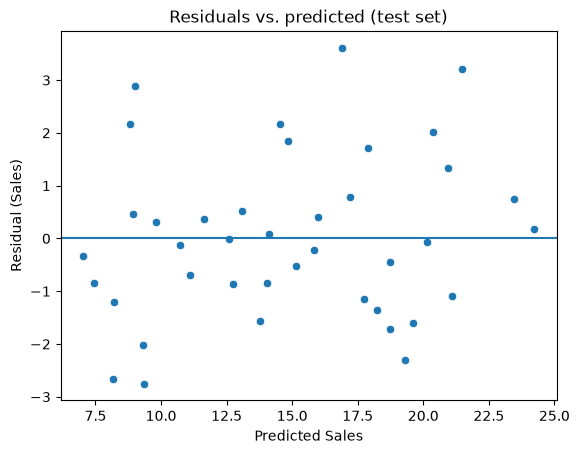

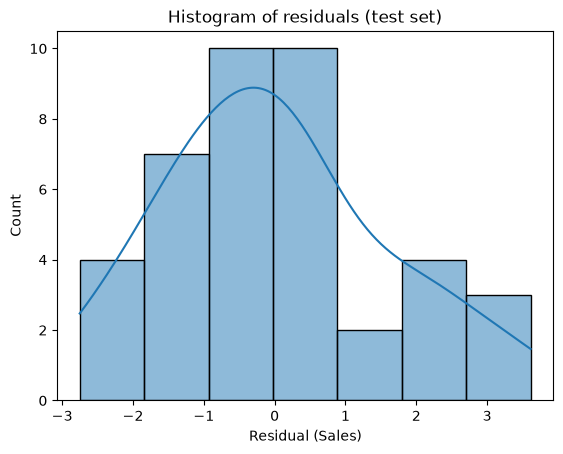

In [62]:
# === Section 5. Evaluate the Model Fit ===

# With regression, we use  R-squared, RMSE, and Residuals

"""
Report test R-squared and RMSE, and show a residual plot.

WHY: These are how the analyst decides
whether the line is a fair description.

This reports them on held-out data;
it does NOT declare the fit good or bad.

The analyst uses the numbers and the residual plot to decide.
"""

y_hat: np.ndarray = model.predict(X_test)

# Use float() to convert from numpy types to native Python types
residuals: np.ndarray = y_test - y_hat
r_squared: float = float(model.score(X_test, y_test))
rmse: float = float(np.sqrt(np.mean(residuals**2)))

LOG.info("Fit numbers on the TEST set (for you to interpret):")
LOG.info(f"  R-squared: {r_squared:.4f}")
LOG.info(f"  RMSE:      {rmse:.6g}  (in units of {TARGET_COL})")

# Residual plot: random scatter around 0 means a straight line fits well.

# Start a new figure
plt.figure()

# Create a scatter plot of residuals vs. predicted values
sns.scatterplot(x=y_hat, y=residuals)

# Add a horizontal line at y=0 to help visualize the residuals
plt.axhline(0)

# Label the axes and add a title
plt.xlabel(f"Predicted {TARGET_COL}")
plt.ylabel(f"Residual ({TARGET_COL})")
plt.title("Residuals vs. predicted (test set)")

# show the plot
plt.show()

# Create a histogram of residuals to check for normality
plt.figure()
sns.histplot(residuals, kde=True)
plt.xlabel(f"Residual ({TARGET_COL})")
plt.title("Histogram of residuals (test set)")
plt.show()

### Interpretation
 The residuals are pretty random about 0, with no obvious curve or funnel, 
so it looks like a straight line (degree=1) provides a good model. 

## Section 6. Detect Over- and Under-Fitting

Fit polynomials of increasing **degree** 
(degree 1 is the straight line) and plot
train vs. test RMSE. 

Underfitting shows as both errors high; 
overfitting shows as train RMSE falling while test RMSE rises. 

The best degree is where **test error is lowest** 
and the train/test gap is small.

The analyst decides which degree that is.

2026-07-26 15:43:45 | DEBUG | M04 |   degree= 1  train RMSE=2.30965  test RMSE=2.22443
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 1  RMSE difference=0.085221
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 2  train RMSE=2.23463  test RMSE=2.1902
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 2  RMSE difference=0.0444302
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 3  train RMSE=2.23442  test RMSE=2.1935
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 3  RMSE difference=0.0409221
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 4  train RMSE=2.20559  test RMSE=2.17212
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 4  RMSE difference=0.0334655
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 5  train RMSE=2.15667  test RMSE=2.09116
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 5  RMSE difference=0.065511
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 6  train RMSE=2.15585  test RMSE=2.09111
2026-07-26 15:43:45 | DEBUG | M04 |   degree= 6  RMSE difference=0.0647318
2026-07-26 15:43:45 | DEBUG | M0

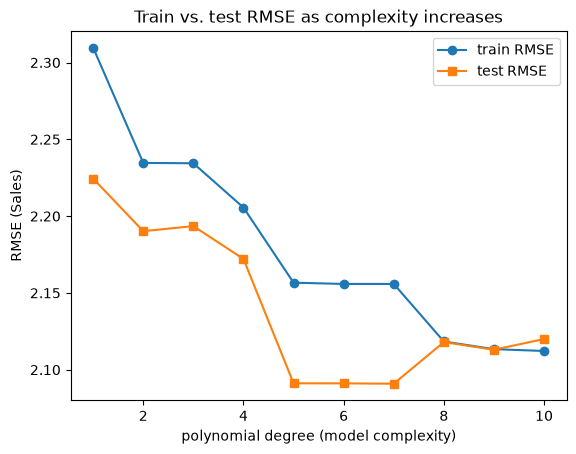

In [68]:
# === Section 6. Detect Over- and Under-Fitting ===

"""Show train vs. test RMSE as polynomial degree increases.

WHY: Error is not a fixed property of "the model"; it moves with complexity.
Watching train and test diverge is how you detect over- and under-fitting and
pick complexity on purpose. numpy fits the polynomial; nothing hidden.
"""

# Call .ravel() to convert from
# shape (n, 1) to shape (n,) for np.polyfit and np.polyval.
x_train: np.ndarray = X_train.ravel()
x_test: np.ndarray = X_test.ravel()

# CUSTOM: ANALYST CHOICE
# for penguins, sweep from 1 to 10 as a good range.
# THIS IS DATA SET DEPENDENT and ANALYST CHOICE.

MAX_SWEEP: Final[int] = 10

# Declare lists to hold the degrees and corresponding train/test RMSE.
degrees: list[int] = list(range(1, MAX_SWEEP + 1))
train_rmse: list[float] = []
test_rmse: list[float] = []

for degree in degrees:
    # Calculate the coefficients of the polynomial fit for the given degree
    # Use one feature (TV) for 1D polynomial fit so x and y lengths match.
    x_train = X_train[:, 0]
    x_test = X_test[:, 0]
    coeffs: np.ndarray = np.polyfit(x_train, y_train, degree)

    # Calculate the predicted values for the training and test sets using the polynomial coefficients
    train_pred: np.ndarray = np.polyval(coeffs, x_train)
    test_pred: np.ndarray = np.polyval(coeffs, x_test)

    # Calculate and store the RMSE for the training and test sets
    train_rmse.append(float(np.sqrt(np.mean((y_train - train_pred) ** 2))))
    test_rmse.append(float(np.sqrt(np.mean((y_test - test_pred) ** 2))))
    LOG.debug(
        f"  degree={degree:2d}  train RMSE={train_rmse[-1]:.6g}  test RMSE={test_rmse[-1]:.6g}"
    )

    # Calculate difference between train and test RMSE for monitoring over- and under-fitting
    rmse_diff: float = abs(train_rmse[-1] - test_rmse[-1])
    LOG.debug(f"  degree={degree:2d}  RMSE difference={rmse_diff:.6g}")


# start a new figure
plt.figure()

# Plot the train and test RMSE against the polynomial degree
# to visualize overfitting and underfitting.
plt.plot(degrees, train_rmse, marker="o", label="train RMSE")
plt.plot(degrees, test_rmse, marker="s", label="test RMSE")

# Label the axes and add a title
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel(f"RMSE ({TARGET_COL})")
plt.title("Train vs. test RMSE as complexity increases")

# Add a legend
plt.legend()

# Show the plot
plt.show()

### Interpretation

As the degree of the polynomial changes, the performance of the regression model changes. From degree 1 to 3, the model is underfitting, as both the training and testing errors remain relatively high. At degree 4, the model begins to improve, with the test RMSE decreasing as the polynomial captures more complexity in the data. The test RMSE reaches its lowest value at degree 7, with only a small gap between the training and testing RMSE, indicating good generalization. After degree 7, the training RMSE continues to decrease while the testing RMSE begins to increase, which is a sign that the model is becoming overfitted. Therefore, degree 7 provides the best predictive performance, while higher-degree models add complexity without improving generalization.

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [69]:
# === Python Summary ===


"""Record what was fit and the judgment still owed."""
slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  {DATASET_NAME}")
LOG.info(
    f"Feature:  {FEATURE_COL_1},{FEATURE_COL_2},{FEATURE_COL_3}  ->  Target: {TARGET_COL}  (regression)"
)
LOG.info(
    f"Line:     {TARGET_COL} = {slope:.6g} * {FEATURE_COL_1} + {slope_2:.6g} * {FEATURE_COL_2} + {slope_3:.6g} * {FEATURE_COL_3} + {intercept:.6g}"
)
LOG.info("========================")

2026-07-26 16:21:02 | INFO | M04 | ========================
2026-07-26 16:21:02 | INFO | M04 | SUMMARY
2026-07-26 16:21:02 | INFO | M04 | ========================
2026-07-26 16:21:02 | INFO | M04 | Dataset:  advertising.csv
2026-07-26 16:21:02 | INFO | M04 | Feature:  TV,Radio,Newspaper  ->  Target: Sales  (regression)
2026-07-26 16:21:02 | INFO | M04 | Line:     Sales = 0.0539592 * TV + 0.101015 * Radio + 0.00746937 * Newspaper + 4.6237
2026-07-26 16:21:02 | INFO | M04 | ========================



### Custom Narrative
I started this project by first sourcing an advertising dataset from the website indicated in the header of ml_04_regression_custom.ipynb. The dataset was then loaded into the notebook using a pandas DataFrame. I inspected the shape of the dataset and checked for missing values, duplicate entries, and outliers. Initially, the dataset contained 200 rows and 4 columns. During the inspection process, two outliers were identified in the Newspaper column. The two rows containing these outliers were removed, leaving us with a final dataset of 198 rows and 4 columns.

I then split the dataset into training and testing sets, using 158 rows for training and 40 rows for testing. Next, I generated a regression equation to describe the relationship between sales and different advertising expenditures. The fitted regression line was:

Sales = 0.0539592 × TV + 0.101015 × Radio + 0.00746937 × Newspaper + 4.6237

I evaluated the performance of the model using several metrics. The model achieved an R-squared value of 0.9130, indicating that advertising spending has a strong influence on sales and explains a large portion of the variation in the data. The RMSE value of 1.55426 dollars is also reasonable, showing that the model's predictions are relatively close to the actual sales values. Additionally, based on the residual plot and histogram, the residuals appear to be approximately normally distributed around zero, with only a few outliers. This behavior suggests that the assumptions of linear regression are mostly satisfied and that a straight-line model is appropriate for this dataset.

I also experimented with polynomial regression models using different degrees. As the polynomial degree increased, the performance of the regression model changed. From degree 1 to degree 3, the model showed signs of underfitting, as both the training and testing RMSE values remained relatively high. Starting at degree 4, the model performance improved as the polynomial captured more complexity in the data and the test RMSE decreased. The lowest test RMSE occurred at degree 7, with only a small difference between the training and testing RMSE, indicating that the model generalized well to unseen data. After degree 7, the training RMSE continued to decrease while the testing RMSE increased, which indicates that the model was beginning to overfit the training data. Therefore, degree 7 provided the best predictive performance, while higher-degree polynomial models increased complexity without improving the model's ability to generalize.
